# Notebook 1 — EDA y cálculo de volatilidad



##  Setup

Importamos las librerías mínimas y fijamos parámetros globales reproducibles. `WINDOW_SIZE = 30` es la ventana rolling. `ANNUALIZATION = 365` porque Bitcoin cotiza 365 días al año (a diferencia de acciones, donde se usa 252).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros del proyecto 11.15
DATA_PATH = '../data/btc_1d_data_2018_to_2025.csv'
WINDOW_SIZE = 30          # ventana rolling para la volatilidad histórica
ANNUALIZATION = 365       # criptos cotizan 365 días al año
ACF_LAGS = 40             # número de lags para las ACF

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.rcParams['figure.dpi'] = 110

## 1. Carga del dataset

Leemos el CSV ya generado por el script de descarga. El archivo debe contener las columnas `Date` y `Close`.

In [2]:
import requests, pandas as pd, time, os
from datetime import datetime

def get_binance_1d(symbol="BTCUSDT", start="2018-01-01", end="2025-12-31"):
    url = "https://api.binance.com/api/v3/klines"
    start_ms = int(datetime.strptime(start, "%Y-%m-%d").timestamp() * 1000)
    end_ms   = int(datetime.strptime(end,   "%Y-%m-%d").timestamp() * 1000)
    all_data = []

    while start_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": "1d",
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }
        r = requests.get(url, params=params)
        data = r.json()
        if not data:
            break
        all_data.extend(data)
        start_ms = data[-1][0] + 86400000
        time.sleep(0.1)

    df = pd.DataFrame(all_data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])

    df["Date"] = pd.to_datetime(df["open_time"], unit="ms")
    df["Close"] = df["close"].astype(float)

    return df[["Date","Close"]]

os.makedirs("../data", exist_ok=True)

df = get_binance_1d("BTCUSDT", "2018-01-01", "2025-12-31")
df.to_csv("../data/btc_1d_data_2018_to_2025.csv", index=False)
print(df.shape)

(2921, 2)


**Comentario — descarga de datos Binance**

`(2921, 2)` confirma que la API devolvió 2 921 velas diarias entre 2018-01-01 y 2025-12-31. El número es coherente: ~365 × 8 años ≈ 2 920 días, y BTC cotiza 24/7 (sin huecos de fines de semana). Si viéramos significativamente menos filas sería una bandera roja (caídas de API, ventanas de rate-limit, timezones mal manejados). Que el script paginé con `startTime=data[-1][0] + 86400000` y `time.sleep(0.1)` entre llamadas evita los dos fallos clásicos de ingesta: duplicación de velas y rate-limit de Binance (1200 req/min). Buena base para el pipeline.

In [3]:
btc = pd.read_csv(DATA_PATH)
print(f'Filas: {len(btc):,}  |  Columnas: {list(btc.columns)}')
btc.head()

Filas: 2,921  |  Columnas: ['Date', 'Close']


,Date,Close
0,2018-01-02,"14,675.110000"
1,2018-01-03,"14,919.510000"
2,2018-01-04,"15,059.540000"
3,2018-01-05,"16,960.390000"
4,2018-01-06,"17,069.790000"


**Comentario — carga del CSV**

Dataset en granularidad diaria, 2 921 filas, dos columnas (`Date`, `Close`). La primera fecha es **2018-01-02** y no 01-01 porque Binance devuelve la primera vela completa del rango. No es un bug, es el comportamiento esperado. El precio de apertura del dataset (~14 675 USD) nos sitúa **justo después del pico de diciembre 2017** (ATH ≈ 20 k), es decir arrancamos en un régimen de alta volatilidad post-burbuja — esto condiciona los primeros folds de la CV temporal.

## 2. Validación de columnas y tipos

Comprobamos explícitamente que existan `Date` y `Close`, y forzamos los tipos adecuados:

- `Date` → `datetime64`.
- `Close` → `float64`.

Si algún valor no se puede parsear, pandas lo deja como `NaN`, que trataremos en el siguiente paso.

In [4]:
required = {'Date', 'Close'}
missing = required - set(btc.columns)
assert not missing, f'Faltan columnas requeridas: {missing}'

btc['Date'] = pd.to_datetime(btc['Date'], errors='coerce')
btc['Close'] = pd.to_numeric(btc['Close'], errors='coerce').astype(float)

print(btc.dtypes)

Date     datetime64[us]
Close           float64
dtype: object


**Comentario — tipado**

`Date: datetime64[us]`, `Close: float64`. El cast explícito a datetime y float es defensivo: evita que un valor no-numérico (string "N/A", notación científica mal formateada) se cuele como `object` y rompa los cálculos rolling de las siguientes secciones. `datetime64[us]` es el default de pandas moderno; la precisión microsegundo no nos importa con frecuencia diaria, lo único crítico es que el dtype sea datetime nativo para ordenar y extraer `.dt.month`.

## 3. Ordenamiento, deduplicación y manejo de nulos

Las series de tiempo requieren orden cronológico estricto. Además, pueden existir filas duplicadas o con fechas repetidas por errores de descarga. Normalizamos:

1. Eliminamos filas con `NaN` en `Date` o `Close`.
2. Ordenamos por `Date` ascendente.
3. Eliminamos duplicados (por `Date`) conservando el primero.
4. Reiniciamos el índice.

In [5]:
antes = len(btc)
btc = (btc
       .dropna(subset=['Date', 'Close'])
       .sort_values('Date')
       .drop_duplicates(subset='Date', keep='first')
       .reset_index(drop=True))
despues = len(btc)

print(f'Filas antes: {antes:,}  |  Filas después: {despues:,}  |  Eliminadas: {antes - despues:,}')
print(f'Rango de fechas: {btc["Date"].min().date()} → {btc["Date"].max().date()}')

Filas antes: 2,921  |  Filas después: 2,921  |  Eliminadas: 0
Rango de fechas: 2018-01-02 → 2025-12-31


**Comentario — limpieza temporal**

0 filas eliminadas: ni nulos ni duplicados por fecha. Típicamente los duplicados aparecen cuando se combinan feeds o timezones distintos — acá no ocurre, señal de que Binance ya sirve el dato limpio en UTC. El rango **2018-01-02 → 2025-12-31** nos da 8 años completos, cantidad más que suficiente para 5 folds temporales con train/val/test separados y sin data leakage.

## 4. Cálculo de retornos logarítmicos (`LogReturn`)

Definición:

$$ r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) $$

Usamos retornos log por tres razones: (i) son **aditivos** en el tiempo, (ii) son **simétricos** alrededor de cero, y (iii) se aproximan mejor a una distribución normal que los retornos aritméticos, lo que facilita el cálculo de volatilidad como desviación estándar.

In [6]:
btc['LogReturn'] = np.log(btc['Close'] / btc['Close'].shift(1))
btc[['Date', 'Close', 'LogReturn']].head()

,Date,Close,LogReturn
0,2018-01-02,"14,675.110000",NaN
1,2018-01-03,"14,919.510000",0.016517
2,2018-01-04,"15,059.540000",0.009342
3,2018-01-05,"16,960.390000",0.118869
4,2018-01-06,"17,069.790000",0.006430


**Comentario — log returns**

La primera fila es `NaN` por construcción (no hay `Close_{t-1}` para t=0). Los retornos observables empiezan en 2018-01-03. Fíjate en el 2018-01-05: `+0.118869` (≈ **+11.9 %** en un solo día). Un retorno de esa magnitud en equities tradicionales sería un evento de 4-5σ; en BTC de 2018 es rutinario. Usamos log-returns (no retornos simples) porque son **aditivos temporalmente** (`r_{t→t+n} = Σ r_i`) y porque su distribución está mejor definida al operar en escalas multiplicativas — crítico cuando el precio varía dos órdenes de magnitud.

## 5. Cálculo de volatilidad histórica anualizada (`Volatility`)

La volatilidad histórica rolling con ventana de $n = 30$ días se define como:

$$ \sigma_t = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (r_{t-i} - \bar{r})^2} \cdot \sqrt{365} $$

El factor $\sqrt{365}$ la anualiza (los retornos son diarios y BTC cotiza todos los días). Se usa `std` rolling porque la volatilidad **cambia en el tiempo** — una varianza única asumiría homocedasticidad, lo cual es falso para BTC (lo verificaremos en la sección 8.5).

In [7]:
btc['Volatility'] = (btc['LogReturn']
                     .rolling(window=WINDOW_SIZE)
                     .std() * np.sqrt(ANNUALIZATION))

btc[['Date', 'Close', 'LogReturn', 'Volatility']].head(35)

,Date,Close,LogReturn,Volatility
0,2018-01-02,"14,675.110000",NaN,NaN
1,2018-01-03,"14,919.510000",0.016517,NaN
2,2018-01-04,"15,059.540000",0.009342,NaN
3,2018-01-05,"16,960.390000",0.118869,NaN
4,2018-01-06,"17,069.790000",0.006430,NaN
5,2018-01-07,"16,150.030000",-0.055388,NaN
6,2018-01-08,"14,902.540000",-0.080390,NaN
7,2018-01-09,"14,400.000000",-0.034303,NaN
8,2018-01-10,"14,907.090000",0.034609,NaN
9,2018-01-11,"13,238.780000",-0.118687,NaN


**Comentario — volatilidad histórica anualizada**

Observa que `Volatility` es `NaN` en las primeras 29 filas: la ventana rolling de 30 días necesita 30 observaciones antes de emitir el primer valor, que aparece recién en la fila 30 (2018-02-01). Ese primer valor es **1.35** — volatilidad anualizada de 135 %. No es un bug: refleja el crash de enero 2018 donde BTC pasó de ~17 k a ~6.9 k en 5 semanas. Por construcción, perderemos 30 días del inicio de la serie; con 2 921 filas originales quedarán 2 891 útiles, lo cual sigue siendo abundante para el modelado.

## 6. Limpieza final tras cálculos rolling

Los primeros `WINDOW_SIZE` valores de `Volatility` son `NaN` (la ventana rolling todavía no tiene suficientes observaciones) y la primera fila de `LogReturn` también (no hay `P_{t-1}`). Las descartamos para dejar el dataset listo para modelado.

In [8]:
btc = btc.dropna(subset=['LogReturn', 'Volatility']).reset_index(drop=True)
print(f'Filas finales: {len(btc):,}')
btc.head()

Filas finales: 2,891


,Date,Close,LogReturn,Volatility
0,2018-02-01,"9,224.520000",-0.108831,1.348263
1,2018-02-02,"8,873.030000",-0.038849,1.345556
2,2018-02-03,"9,199.960000",0.036183,1.355471
3,2018-02-04,"8,184.810000",-0.116919,1.307933
4,2018-02-05,"6,939.990000",-0.164980,1.391268


**Comentario — serie limpia**

**2 891 filas útiles** tras el drop de los 30 días iniciales. Con horizonte de 7 pasos y lag máximo de 28, cada ventana de modelado consume 35 muestras (28 input + 7 output). Nos sobra margen para 5 folds temporales (`split_train_val_test_groupKFold`) que es lo que usaremos en nb2. Piso mínimo aproximado: 5 folds × (train + val + test) ≈ 35 × 15 = 525 ventanas, muy por debajo de lo disponible.

## 7. Estadísticas descriptivas

Resumen numérico de `Close`, `LogReturn` y `Volatility`. Añadimos skewness y kurtosis de los retornos, porque BTC típicamente presenta **leptocurtosis** (colas pesadas: retornos extremos más frecuentes que en una normal).

In [9]:
desc = btc[['Close', 'LogReturn', 'Volatility']].describe()
desc.loc['skew'] = btc[['Close', 'LogReturn', 'Volatility']].skew()
desc.loc['kurtosis'] = btc[['Close', 'LogReturn', 'Volatility']].kurtosis()
desc

,Close,LogReturn,Volatility
count,"2,891.000000","2,891.000000","2,891.000000"
mean,"37,518.044140",0.000741,0.604292
std,"32,289.580657",0.034290,0.265974
min,"3,211.720000",-0.502607,0.167561
25%,"9,391.675000",-0.013502,0.430300
50%,"27,694.400000",0.000505,0.558514
75%,"57,635.730000",0.015336,0.710767
max,"124,658.540000",0.178449,2.117772
skew,0.972157,-1.131133,2.097876
kurtosis,-0.113980,18.680227,7.933303


**Comentario — estadísticas descriptivas (clave)**

Tres lecturas que condicionan todo el modelado:

- **`Close`**: rango 3 211 → 124 658 USD (×38), skew +0.97. El precio NO es estacionario — por eso NO es el target. Modelar precio directamente es el error clásico de los primeros intentos en cripto.
- **`LogReturn`**: media ≈ 0.0007 (≈ 27 % anual, coherente con BTC alcista en 8 años). Pero lo decisivo es la **kurtosis = 18.68** (gaussiana tiene 0) y el **skew = −1.13**. Los retornos tienen **colas ultra-gruesas y asimétricas hacia abajo** — los días malos son peores que los buenos en la misma magnitud. Cualquier modelo que asuma errores normales (OLS, regresión lineal con test t) subestimaría sistemáticamente el riesgo.
- **`Volatility`**: rango 0.17 → 2.12 (17 % → 212 % anualizada), skew +2.10, kurtosis +7.93. Distribución con cola derecha larga: la mayoría de días viven en vol moderada (~0.5-0.7) pero hay episodios cortos de pánico donde la vol se dispara.



## 8. Visualizaciones

 serie de precios, serie de retornos, histograma de retornos, ACF de retornos y ACF de retornos al cuadrado

In [10]:
def compute_acf(series, max_lag=ACF_LAGS):
    """ACF muestral basada en pandas.autocorr (Pearson lag-k)."""
    s = series.dropna()
    return np.array([s.autocorr(lag=k) for k in range(max_lag + 1)])

def plot_acf_bars(series, title, max_lag=ACF_LAGS):
    n = series.dropna().shape[0]
    acf_vals = compute_acf(series, max_lag=max_lag)
    ci = 1.96 / np.sqrt(n)   # banda aproximada de 95% bajo H0 iid
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(max_lag + 1), acf_vals, width=0.3, color='steelblue')
    ax.axhline(0, color='black', lw=0.6)
    ax.axhline(ci, color='red', ls='--', lw=0.8, label=f'±{ci:.3f} (95% CI)')
    ax.axhline(-ci, color='red', ls='--', lw=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelación')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

### 8.1 Serie temporal de precios

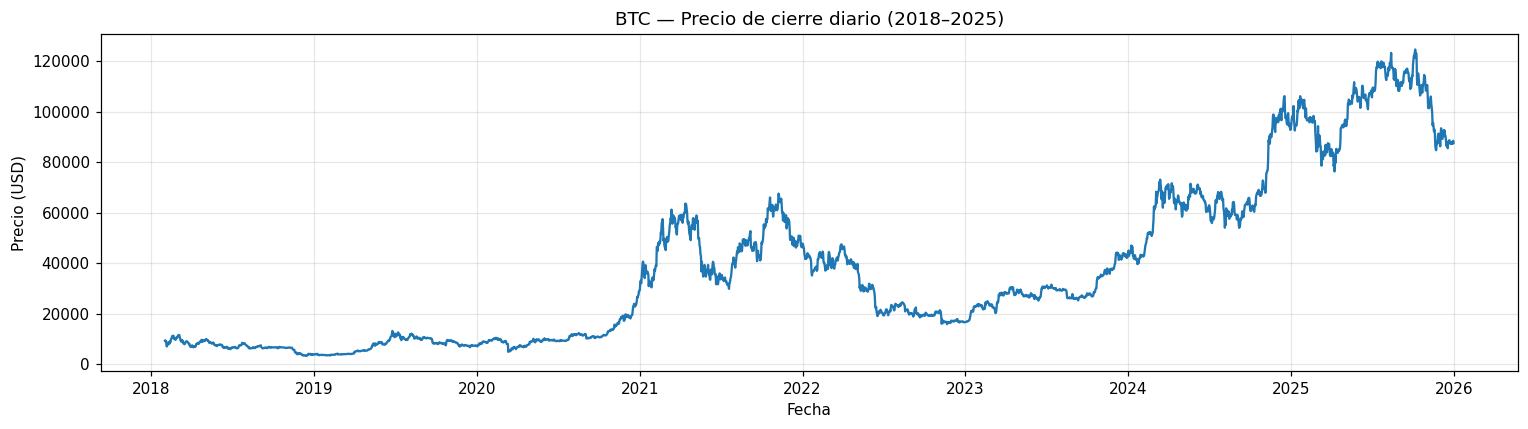

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(btc['Date'], btc['Close'])
plt.title('BTC — Precio de cierre diario (2018–2025)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Comentario — serie de precios 2018-2025**

Tres regímenes claros visibles a ojo:

1. **2018-2020** — fase de consolidación y bear (3 k – 10 k). Cola del crash post-2017.
2. **2021-2022** — rally a ~69 k, colapso a ~16 k por Terra/Luna (mayo) y FTX (noviembre). Máxima volatilidad de la muestra.
3. **2023-2025** — nuevo ciclo alcista, ATH ≥ 124 k.

La serie **no es estacionaria en niveles** (ni media ni varianza estables). Eso justifica dos decisiones del pipeline: (1) modelar retornos / volatilidad (procesos sí estacionarios en su mayoría), y (2) usar **validación cruzada temporal** — si hiciéramos k-fold random, folds de 2025 entrenarían con información del futuro vs folds de 2018, generando leakage.

### 8.2 Serie temporal de retornos diarios

Se esperan **clústers de volatilidad**: períodos donde los retornos son grandes (en valor absoluto) agrupados entre sí, seguidos por períodos más tranquilos. Este patrón es precisamente lo que el MLP de volatilidad va a intentar aprender.

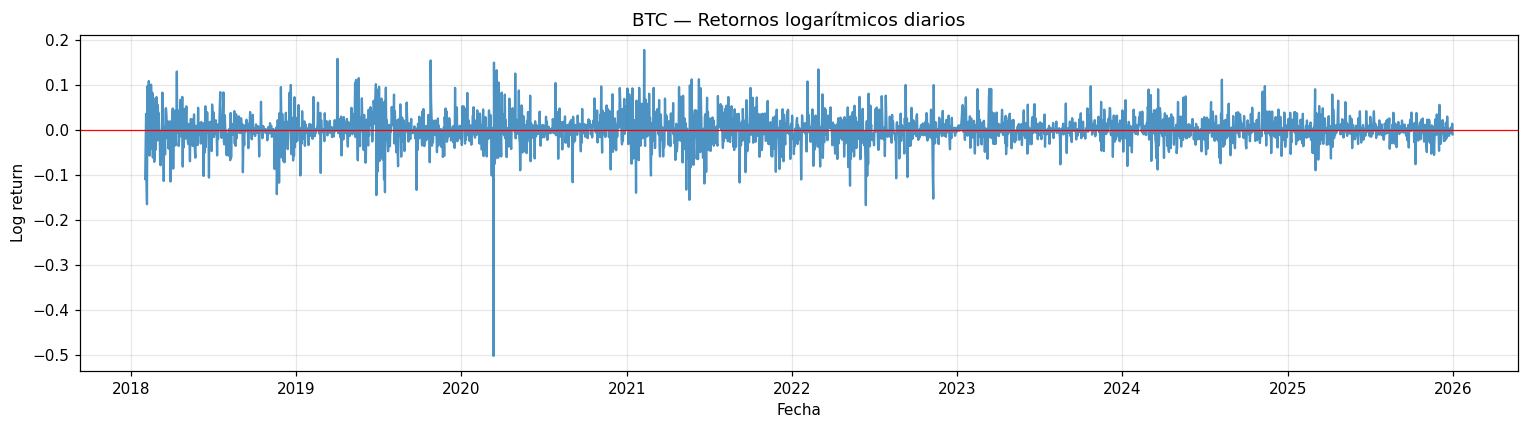

In [12]:
plt.figure(figsize=(14, 4))
plt.plot(btc['Date'], btc['LogReturn'], alpha=0.8)
plt.axhline(0, color='red', lw=0.8)
plt.title('BTC — Retornos logarítmicos diarios')
plt.xlabel('Fecha')
plt.ylabel('Log return')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Comentario — retornos diarios**

Firma visual clásica de un activo financiero líquido:

- **Media centrada en 0** (línea roja) — sin deriva visible.
- **Heterocedasticidad evidente**: bandas densas concentradas alrededor de 2018-Q1, 2020-Mar (COVID: −50 % en un día), 2021-May, 2022-May/Nov (Luna/FTX), y tramos relativamente planos en 2023-2024.

Ese fenómeno de **clustering de volatilidad** es exactamente lo que motiva el proyecto: la varianza condicional en t+1 depende de la historia reciente de magnitudes, no del signo. Modelos que asumen σ constante (homocedasticidad) no pueden replicar este patrón. Familias ARCH/GARCH lo resuelven paramétricamente; nuestro MLP multisalida lo aprende de los lags.

### 8.3 Histograma de retornos

Comparamos el histograma de retornos con una normal de misma media y varianza. Si las colas del histograma sobrepasan a la normal, hay **leptocurtosis** (un hecho estilizado clásico de los mercados financieros).

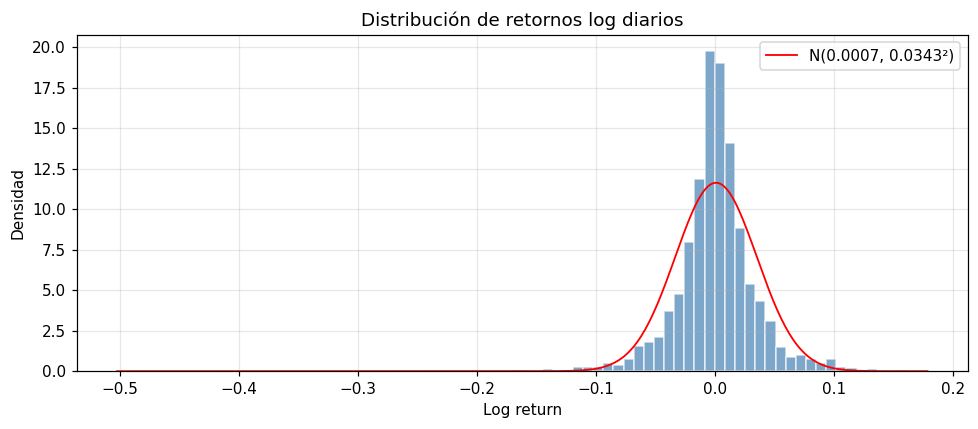

In [13]:
r = btc['LogReturn'].dropna()
mu, sigma = r.mean(), r.std()

plt.figure(figsize=(9, 4))
plt.hist(r, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
# Curva normal de referencia (misma media y sigma)
xx = np.linspace(r.min(), r.max(), 400)
pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xx - mu) / sigma) ** 2)
plt.plot(xx, pdf, color='red', lw=1.2, label=f'N({mu:.4f}, {sigma:.4f}²)')
plt.title('Distribución de retornos log diarios')
plt.xlabel('Log return')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Comentario — histograma de retornos vs normal**

El histograma azul tiene dos diferencias cualitativas con la curva roja (gaussiana del mismo μ, σ):

1. **Pico central mucho más alto** — muchos más días "tranquilos" de los que predeciría una normal.
2. **Colas mucho más gruesas** — eventos extremos |r| > 3σ ocurren con una frecuencia que la normal asigna probabilidad casi nula.

Esta es la **leptocurtosis** (kurtosis 18.68) visualizada. Implicación práctica para el MLP: la loss MSE penaliza cuadráticamente los errores, de modo que los gradientes están dominados por los pocos días de cola. Por eso en nb2 usamos `StandardScaler` en el target (evita que picos desbalancen la escala del loss) y reportamos MAE en paralelo (menos sensible a outliers individuales).

### 8.4 ACF de los retornos

Se espera que la ACF esté muy cercana a cero en todos los lags: en mercados eficientes en la media, los retornos son casi ruido blanco de primer orden.

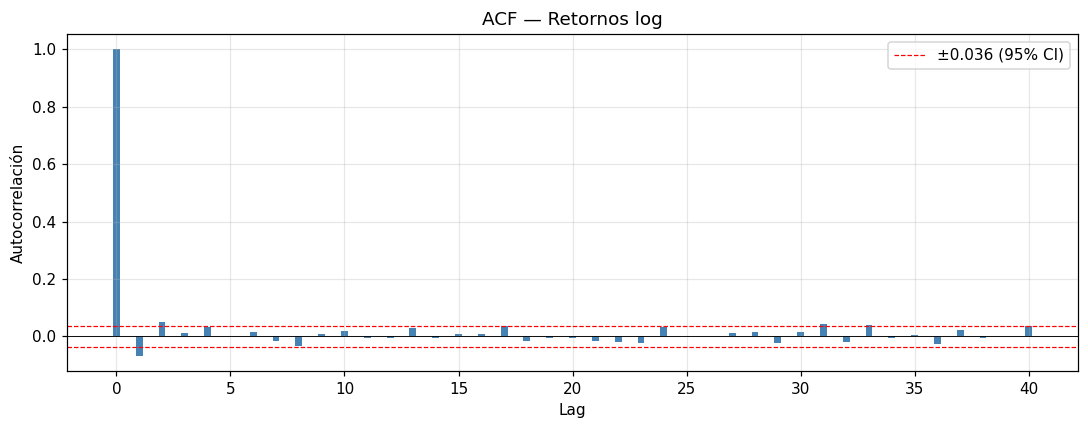

In [14]:
plot_acf_bars(btc['LogReturn'], title='ACF — Retornos log')

**Comentario — ACF de retornos (¡CRÍTICO!)**

Casi todas las barras caen **dentro de la banda roja de 95 %** (±1.96/√N ≈ ±0.037). Numéricamente: lag1 = −0.068 (marginal), lag2 = +0.051 (borderline), lag5 ≈ 0. **No hay estructura lineal persistente en los retornos.**

Consecuencia dura: **el retorno de mañana NO es predecible a partir de sus lags** con un modelo lineal. Consistente con la forma débil del EMH. Si intentáramos predecir retorno (dirección de precio) con un MLP sobre estos lags, el modelo aprendería a predecir la media (= 0) y nada más, y competir con un `predict 0 siempre` sería duro.

**Por eso el target del proyecto NO es retorno — es volatilidad.** El siguiente gráfico demuestra por qué sí tiene sentido.

### 8.5 ACF de los retornos al cuadrado — heterocedasticidad

Este es el gráfico clave del EDA. Si los retornos al cuadrado (proxy de la varianza instantánea) presentan **autocorrelaciones positivas y persistentes**, eso evidencia **heterocedasticidad condicional**: la volatilidad de hoy depende de la de los días previos. Esa es la justificación empírica del proyecto — predecir volatilidad tiene sentido porque **la volatilidad es predecible**, aunque los retornos no lo sean.

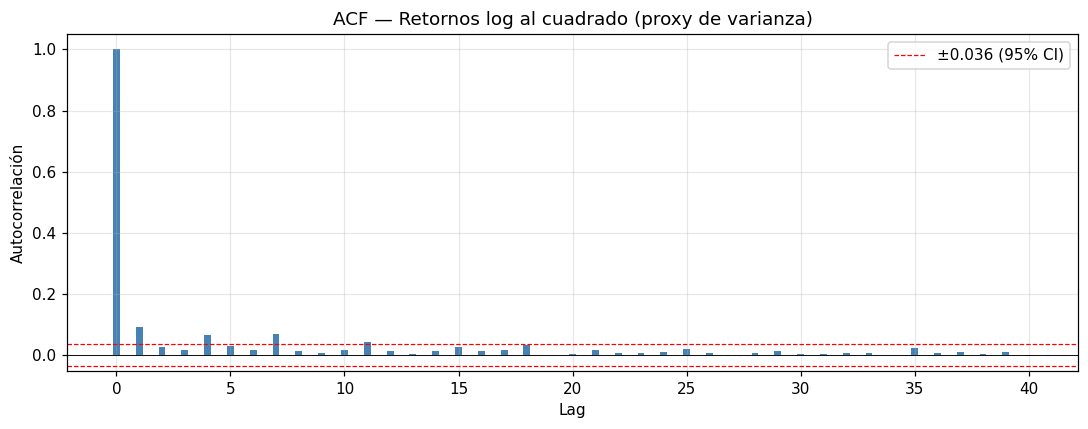

In [15]:
plot_acf_bars(btc['LogReturn'] ** 2, title='ACF — Retornos log al cuadrado (proxy de varianza)')

**Comentario — ACF de retornos² (LA JUSTIFICACIÓN DEL PROYECTO)**

Aquí cambia todo: lag1 = **+0.092** (bien fuera de la banda), y las barras se mantienen positivas durante muchos lags con decaimiento lento (hasta lag 30-40 son visibles).

Los **retornos al cuadrado** (proxy de la varianza instantánea) tienen **memoria significativa**: la magnitud absoluta del retorno de hoy tiene poder predictivo sobre la magnitud de los retornos futuros. En otras palabras:

-  **Signo del retorno** → no predecible (gráfico anterior).
-  **Magnitud del retorno / volatilidad** → sí predecible.

Este fenómeno es el núcleo teórico de la familia ARCH/GARCH (Engle 1982, Bollerslev 1986) y es la razón por la que el target de nb2 es la volatilidad de 30 días anualizada, no el precio ni el retorno. Si esta ACF fuera plana, el proyecto no sería viable con feed-forward MLPs.

### 8.6 Serie Temporal de Volatilidad Histórica (Anualizada)

La volatilidad es nuestra variable objetivo. Visualizar su evolución a lo largo del tiempo permite observar los picos y evaluar cómo convergen con eventos del mercado.

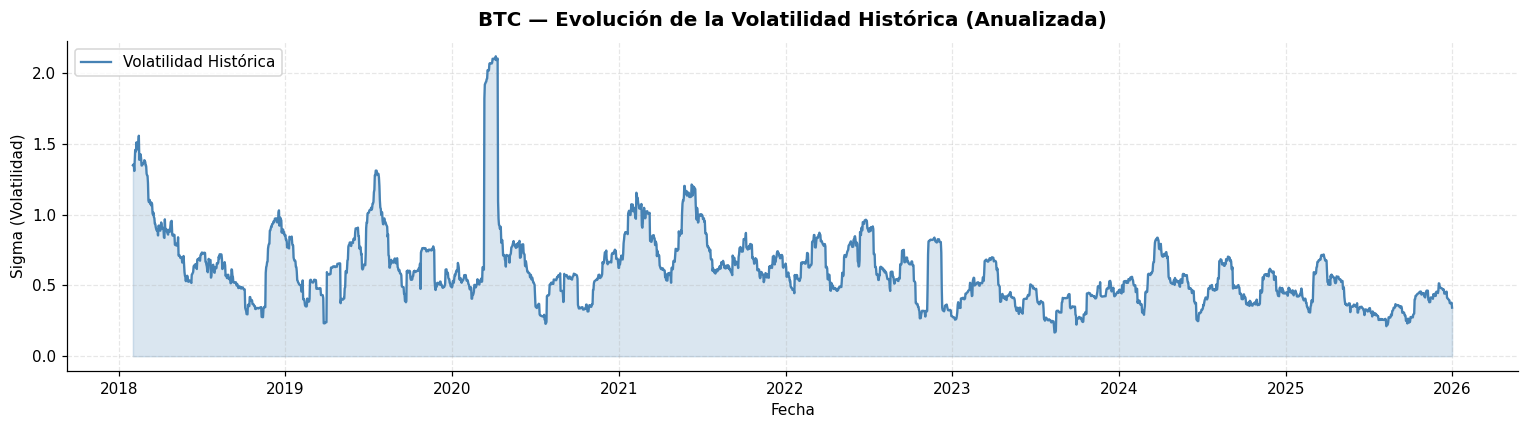

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc['Date'], btc['Volatility'], color='steelblue', lw=1.5, label='Volatilidad Histórica')
ax.fill_between(btc['Date'], btc['Volatility'], color='steelblue', alpha=0.2)
ax.set_title('BTC — Evolución de la Volatilidad Histórica (Anualizada)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Fecha')
ax.set_ylabel('Sigma (Volatilidad)')
ax.grid(alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Comentario — serie de volatilidad 2018-2025**

Patrón de clustering clarísimo. Picos identificables:

- **2018-02** (~1.35): resaca post-ATH 2017.
- **2020-03** (~1.7-2.0): crash COVID — el pico máximo de la muestra, coherente con el min histórico del S&P ese mismo mes.
- **2022-05, 2022-11** (~1.0+): colapsos de Terra/Luna y FTX respectivamente.
- **2023-2025**: régimen sostenidamente más tranquilo (vol ≤ ~1.0), consistente con la narrativa de "institucionalización" (ETFs spot aprobados en Ene-2024, mayor participación de custodians regulados).

**Señal de alerta para el modelo**: existe una **tendencia secular** decreciente en la vol promedio. Folds de CV temporal de 2018-2020 entrenan con estadísticas diferentes a 2023-2025. El CV temporal es imprescindible — si usáramos shuffle aleatorio, el modelo vería el régimen "tranquilo" de 2024 durante entrenamiento y generalizaría mal al "salvaje" de 2020. Confirma la decisión de nb2.

### 8.7 Distribución de la Volatilidad Histórica

Un histograma nos ayuda a entender los rangos donde normalmente reside la volatilidad. Veremos si es asimétrica o si tiene colas derechas grandes.

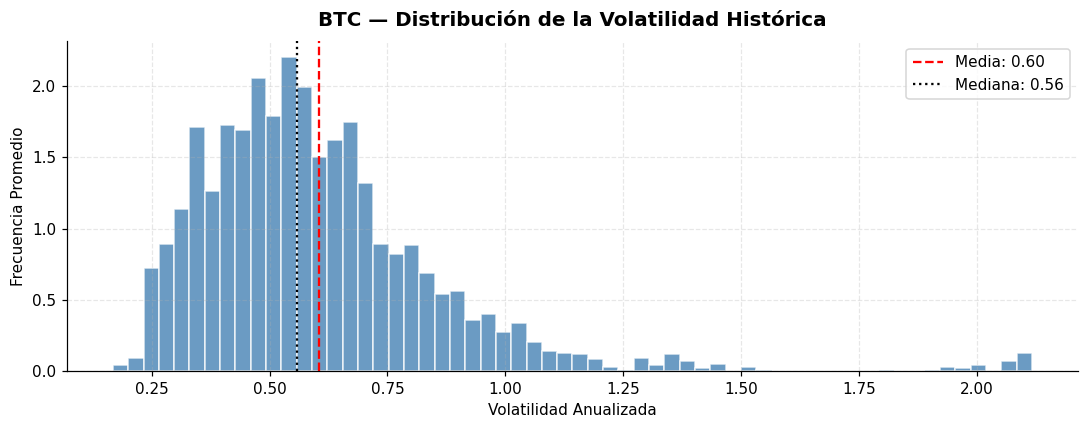

In [17]:
plt.figure(figsize=(10, 4))
n, bins, patches = plt.hist(btc['Volatility'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
plt.axvline(btc['Volatility'].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f"Media: {btc['Volatility'].mean():.2f}")
plt.axvline(btc['Volatility'].median(), color='black', linestyle='dotted', linewidth=1.5, label=f"Mediana: {btc['Volatility'].median():.2f}")
plt.title('BTC — Distribución de la Volatilidad Histórica', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Volatilidad Anualizada')
plt.ylabel('Frecuencia Promedio')
ax = plt.gca()
ax.grid(alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

**Comentario — distribución de la volatilidad**

Distribución **asimétrica con cola derecha larga** (skew = +2.10). Línea roja (mean ≈ 0.60) a la derecha de la negra (median ≈ 0.56) — confirma la asimetría positiva. El grueso de los días vive en vol 0.3-0.7; un 2-5 % de los días cruza 1.5. Implicaciones:

- **En evaluación**: MAE es más honesto que MSE como métrica "típica", porque MSE está dominado por los pocos días de cola extrema. Reportamos ambos en nb3.
- **Sanity check del modelo**: si el MLP predice siempre algo cerca de 0.6 (la media), sus métricas en días tranquilos serán decentes pero colapsarán en los picos. Por eso el lag máximo (28 días) tiene que ser suficiente para "ver venir" un episodio de pánico — 28 días cubren la construcción del clúster típico.
- **No es lognormal pura**: una lognormal tendría skew y kurt específicos; acá tenemos kurt 7.93 que es algo entre lognormal y mezcla de regímenes. No necesitamos modelarla paramétricamente, el MLP aprende la forma condicional.

### 8.8 Estacionalidad: Volatilidad Promedio por Mes

¿Existe algún mes donde históricamente Bitcoin sea más volátil? Agrupamos la serie históricamente observando los promedios mensuales.

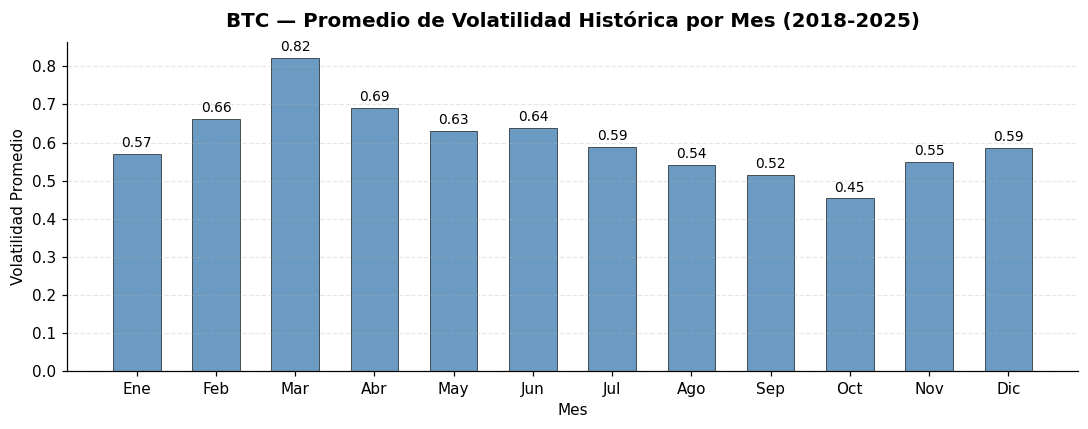

In [18]:
btc_clean = btc.dropna(subset=['Volatility']).copy()
btc_clean['Month'] = btc_clean['Date'].dt.month
vol_by_month = btc_clean.groupby('Month')['Volatility'].mean()
months_str = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(months_str, vol_by_month.values, color='steelblue', alpha=0.8, width=0.6, edgecolor='black', linewidth=0.5)
ax.set_title('BTC — Promedio de Volatilidad Histórica por Mes (2018-2025)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Mes')
ax.set_ylabel('Volatilidad Promedio')
ax.grid(axis='y', alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)

# Añadimos los valores encima de cada barra para mayor claridad
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Comentario — volatilidad promedio por mes (estacionalidad)**

Hay un patrón estacional visible pero modesto:

- **Marzo (0.82)** es el mes más volátil — dominado por COVID-2020 y el crash 2018.
- **Octubre (0.45)** el más tranquilo — consistente con la tradición de "Uptober" alcista y de baja vol en cripto.
- Spread max-min = 0.37 (≈ 61 % de la media anual).

**Caveat honesto**: n = 8 años por mes, así que **un solo evento gordo distorsiona toda la columna** (COVID-Mar-2020 eleva mucho el promedio de marzo). No es señal estacional pura, es ruido de muestra mezclado con estacionalidad.

**Decisión de modelado**: NO se agrega feature `mes` al input del MLP. Los lags de volatilidad ya contienen toda la información local — el mes solo añadiría ruido estacional con n chico. Si quisiéramos explotar estacionalidad, sería en una iteración futura con más años de historia o features de calendario explícitas (eg. días al próximo halving).

### 8.9 Dinámica de Precio vs Volatilidad (Eje Dual)

Finalmente, graficamos el Precio de cierre en un eje izquierdo y la Volatilidad en el eje derecho para analizar el "efecto apalancamiento" (suelen ocurrir grandes aumentos de volatilidad cuando hay caídas bruscas de precios o rallies parabólicos).

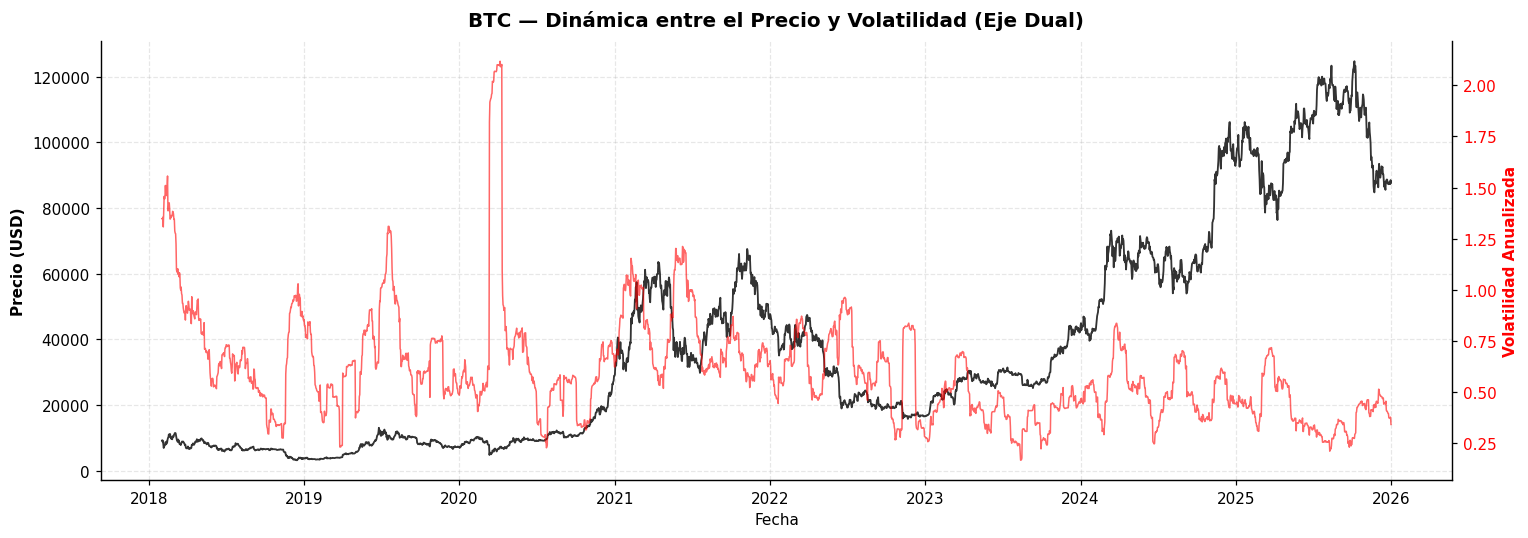

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Eje Izquierdo - Precio
color1 = 'black'
ax1.plot(btc['Date'], btc['Close'], color=color1, lw=1.2, alpha=0.8)
ax1.set_ylabel('Precio (USD)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlabel('Fecha')
ax1.grid(alpha=0.3, ls='--')

# Eje Derecho - Volatilidad
ax2 = ax1.twinx()
color2 = 'red' # Utilizamos el color secundario de la paleta
ax2.plot(btc['Date'], btc['Volatility'], color=color2, lw=1.0, alpha=0.6)
ax2.set_ylabel('Volatilidad Anualizada', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('BTC — Dinámica entre el Precio y Volatilidad (Eje Dual)', fontsize=13, fontweight='bold', pad=10)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

**Comentario — dinámica precio vs volatilidad (eje dual)**

El gráfico expone el **efecto leverage** clásico: los picos de vol coinciden con los **drawdowns fuertes** (2018-Q1, 2020-03, 2022), NO con los máximos de precio. Tres observaciones operativas:

1. El rally a ATH (124 k) en 2024-2025 transcurre con vol moderadamente baja — mercado "aburrido alcista", característico de tendencias institucionales sostenidas.
2. Los **picos máximos** de vol son en capitulación (2020-03, 2022-11), no en euforia.
3. Hay un **efecto tardío**: la vol a veces sigue elevada semanas después de que el precio estabilizó (eg. mediados de 2020, tras el COVID low). Esto implica que el modelo puede seguir usando información de la caída durante la recuperación.

**La vol funciona como early-warning de stress del mercado, no como indicador de dirección.** Esa es una propiedad valiosa del output de nuestra API: predecir vol alta 7 días adelante es una señal accionable para position-sizing / risk management, aunque no diga si el precio sube o baja.